Parámetros de adquisición
  equipment           : Nikon XT H 225
  energy_kV           : 150
  pixel_size_um       : 20
  material            : Mortero de cemento
  phases              : ['Poros', 'Resina', 'Matriz de cemento']


Información de la imagen
  Dimensiones        : 1180 x 1188 píxeles
  Campo de visión    : 23.60 x 23.76 mm
  Tipo de dato       : uint16
  Valor mínimo       : 4930
  Valor máximo       : 59483
  Media              : 24073.0
  Desviación estándar: 10078.8


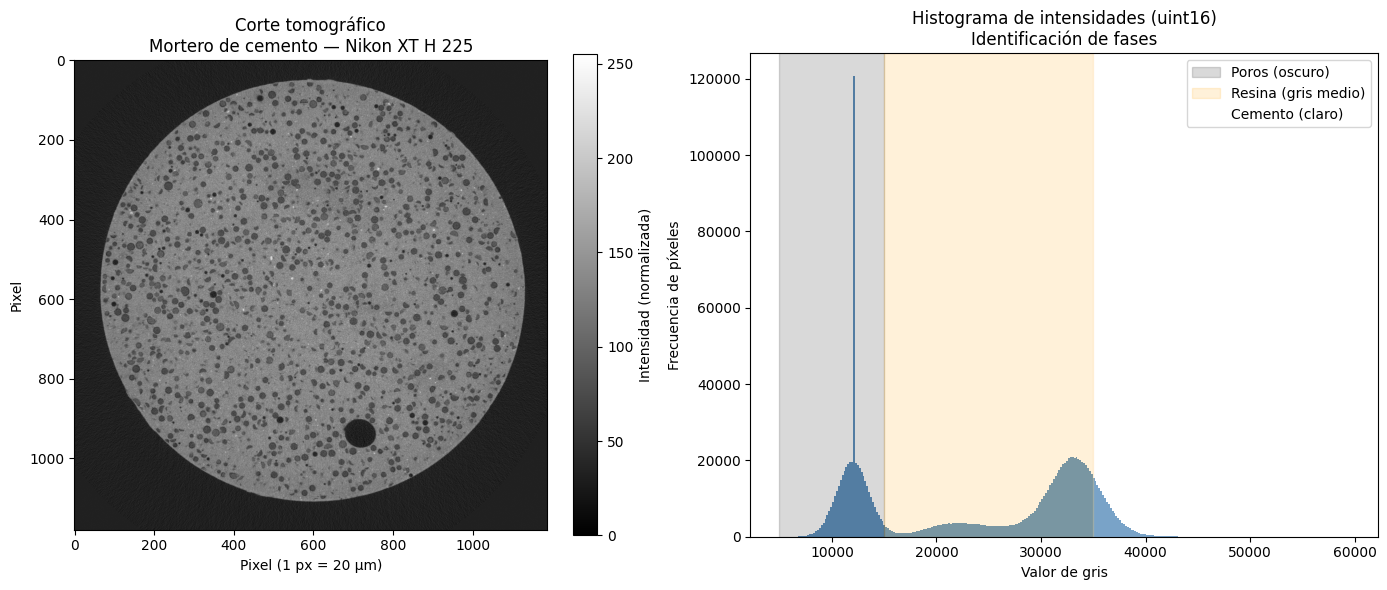


  Figura guardada en: C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis\figures\01_exploracion_imagen.png


In [1]:
# ============================================================
# PROYECTO 01 - Análisis de Porosidad en Mortero de Cemento
# 1. Exploración y comprensión de los datos
# ============================================================
# Autor: Peter Zabala Medina, PhD
# Equipo: Nikon XT H 225
# ============================================================

import numpy as np
import tifffile
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ------------------------------------------------------------
# 1.1 - Parámetros de adquisición
# ------------------------------------------------------------
# Estos parámetros convierten los resultados de píxeles a 
# unidades físicas reales. Son la base de todo el análisis.

ACQUISITION_PARAMS = {
    "equipment"  : "Nikon XT H 225",
    "energy_kV"  : 150,
    "pixel_size_um": 20,        # micrones por pixel
    "material"   : "Mortero de cemento",
    "phases"     : ["Poros", "Resina", "Matriz de cemento"],
}

print("=" * 50)
print("Parámetros de adquisición")
print("=" * 50)
for key, value in ACQUISITION_PARAMS.items():
    print(f"  {key:20s}: {value}")

# ------------------------------------------------------------
# 1.2 - Rutas del proyecto
# ------------------------------------------------------------

BASE_DIR    = Path(r"C:\Users\Peter\ai-imaging-portfolio\projects\01_mortar_porosity_analysis")
DATA_RAW    = BASE_DIR / "data" / "raw"
FIGURES_DIR = BASE_DIR / "figures"
RESULTS_DIR = BASE_DIR / "results"

IMAGE_PATH  = DATA_RAW / "Mortero5bin20821.tif"

# ------------------------------------------------------------
# 1.3 - Carga de imagen
# Nota: esta función es el punto de entrada del pipeline.
# En el proyecto 3D, se llamará una vez por corte dentro
# de un loop de procesamiento por lotes.
# ------------------------------------------------------------

def load_image(path: Path) -> np.ndarray:
    """
    Carga una imagen TIFF de cortes tomográficos.
    
    Parameters
    ----------
    path : Path
        Ruta al archivo .tif
    
    Returns
    -------
    np.ndarray
        Imagen en formato uint16
    """
    img = tifffile.imread(path)
    return img

img = load_image(IMAGE_PATH)

# ------------------------------------------------------------
# 1.4 - Información básica de la imagen
# ------------------------------------------------------------

pixel_size  = ACQUISITION_PARAMS["pixel_size_um"]
height, width = img.shape
fov_mm = (height * pixel_size / 1000, width * pixel_size / 1000)

print("\n")
print("=" * 50)
print("Información de la imagen")
print("=" * 50)
print(f"  Dimensiones        : {height} x {width} píxeles")
print(f"  Campo de visión    : {fov_mm[0]:.2f} x {fov_mm[1]:.2f} mm")
print(f"  Tipo de dato       : {img.dtype}")
print(f"  Valor mínimo       : {img.min()}")
print(f"  Valor máximo       : {img.max()}")
print(f"  Media              : {img.mean():.1f}")
print(f"  Desviación estándar: {img.std():.1f}")

# ------------------------------------------------------------
# 1.5 - Visualización exploratoria
# ------------------------------------------------------------

def plot_exploration(img: np.ndarray, params: dict, save_path: Path) -> None:
    """
    Genera figura exploratoria con imagen e histograma de intensidades.
    Identifica visualmente las fases presentes en la muestra.

    Parameters
    ----------
    img     : np.ndarray  Imagen tomográfica uint16
    params  : dict        Parámetros de adquisición
    save_path : Path      Ruta donde guardar la figura
    """
    # Normalizar a uint8 solo para visualización
    img_vis = ((img - img.min()) / (img.max() - img.min()) * 255).astype(np.uint8)

    fig = plt.figure(figsize=(14, 6))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.2])

    # --- Imagen ---
    ax0 = fig.add_subplot(gs[0])
    im  = ax0.imshow(img_vis, cmap="gray")
    ax0.set_title(f"Corte tomográfico\n{params['material']} — {params['equipment']}", fontsize=12)
    ax0.set_xlabel(f"Pixel (1 px = {params['pixel_size_um']} µm)")
    ax0.set_ylabel("Pixel")
    plt.colorbar(im, ax=ax0, fraction=0.046, label="Intensidad (normalizada)")

    # --- Histograma ---
    ax1 = fig.add_subplot(gs[1])
    ax1.hist(img.ravel(), bins=300, color="steelblue", alpha=0.85, linewidth=0.3)
    ax1.set_title("Histograma de intensidades (uint16)\nIdentificación de fases", fontsize=12)
    ax1.set_xlabel("Valor de gris")
    ax1.set_ylabel("Frecuencia de píxeles")

    # Anotaciones de fases (aproximadas — se ajustan en 3)
    ax1.axvspan(img.min(), 15000, alpha=0.15, color="black",  label="Poros (oscuro)")
    ax1.axvspan(15000,     35000, alpha=0.15, color="orange", label="Resina (gris medio)")
    ax1.axvspan(35000, img.max(), alpha=0.15, color="white",  label="Cemento (claro)")
    ax1.legend(fontsize=10)

    plt.tight_layout()
    out = save_path / "01_exploracion_imagen.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  Figura guardada en: {out}")

plot_exploration(img, ACQUISITION_PARAMS, FIGURES_DIR)